# 04 — Random Forest & Gradient Boosting Models

Builds and compares two tree-based ensemble models to predict `tickets_scanned` for OHL home matches.

Feature prep = same features and encoding as the baseline linear model (notebook 04_baseline)

Train/test split = Time-based: train on 22/23–24/25, test on 25/26

Random Forest — bagging ensemble of decision trees; reduces variance by averaging many trees

Gradient Boosting — sequential boosting ensemble; iteratively corrects residuals

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# --- Global plot style (matches baseline notebook) ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi':          130,
    'font.family':         'sans-serif',
    'font.size':           12,
    'axes.titlesize':      14,
    'axes.titleweight':    'bold',
    'axes.titlepad':       12,
    'axes.labelsize':      12,
    'axes.labelpad':       8,
    'xtick.labelsize':     11,
    'ytick.labelsize':     11,
    'legend.fontsize':     11,
    'legend.framealpha':   0.8,
    'axes.spines.top':     False,
    'axes.spines.right':   False,
})

df = pd.read_csv('../data/cleaned/engineered_df.csv')
df['match_date'] = pd.to_datetime(df['match_date'])

print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Loaded: 71 rows, 41 columns


# 1 — Feature Preparation

Identical feature set to the baseline model to ensure a fair comparison.

## Features Used

| Feature | Type | Notes |
|--------|------|------|
| `opponent_grouped` | Categorical | 16 groups; singletons collapsed to "Other" in notebook 03 |
| `is_playoff` | Binary | Derived from `stage`: Conference League = 1, Regular Season = 0 |
| `last_h2h_result` | Categorical | W/D/L; 3 NaNs filled with "Unknown" |
| `kickoff_hour` | Numeric | Extracted from `kickoff_time_local` |
| `is_weekend` | Binary | 58 of 71 matches on a weekend |
| `is_school_holiday_flanders` | Binary | 22 of 71 matches during school holidays |
| `has_promotion` | Binary | 26 of 71 matches had a ticketing promotion |
| `has_campaign` | Binary | Sustained marketing campaign flag — distinct from one-off promotions |
| `weather_score` | Numeric | Composite weather quality score |
| `avg_ohl_interest_7d` | Numeric | Google Trends 7-day average before match |
| `pre_match_interest_ratio` | Numeric | `avg_ohl_interest_7d / season_mean` — within-season relative buzz (Google Trends resets between seasons) |
| `pre_match_article_count` | Numeric | Press articles before match; 4 NaNs filled with median |
| `home_win_rate_last3` | Numeric | OHL home win rate over last 3 games; 1 NaN (first match) filled with 0 |
| `rolling_avg_attendance_last3` | Numeric | Average attendance over last 3 home games; 1 NaN (first match) filled with median |
| `ohl_season_points` | Numeric | OHL cumulative points before this match |
| `ohl_points_per_game` | Numeric | `ohl_season_points / matchday` — normalised form rate, comparable across the season |
| `matchday_normalized` | Numeric | `matchday / season_max_matchday` (0→1) — captures season phase; late-season games draw +40% more fans |
| `opp_ppg_vs_ohl` | Numeric | Opponent historical points-per-game vs OHL |
| `last_h2h_goal_margin` | Numeric | `last_h2h_ohl_goals − last_h2h_opponent_goals`; richer than W/D/L alone |

In [38]:
model_df = df.copy()

# --- Derived features ---
model_df['kickoff_hour'] = pd.to_datetime(
    model_df['kickoff_time_local'], format='%H:%M:%S'
).dt.hour

model_df['is_playoff'] = (model_df['stage'] == 'Conference League Play-off Group').astype(int)

# --- Fill nulls ---
model_df['last_h2h_result'] = model_df['last_h2h_result'].fillna('Unknown')
model_df['home_win_rate_last3'] = model_df['home_win_rate_last3'].fillna(0)
model_df['pre_match_article_count'] = model_df['pre_match_article_count'].fillna(
    model_df['pre_match_article_count'].median()
)
# rolling_avg_attendance_last3: 1 NaN for the very first match — fill with overall median
model_df['rolling_avg_attendance_last3'] = model_df['rolling_avg_attendance_last3'].fillna(
    model_df['rolling_avg_attendance_last3'].median()
)

# --- Select columns ---
FEATURES_NUM = [
    # --- existing ---
    'kickoff_hour', 'is_playoff', 'is_weekend',
    'is_school_holiday_flanders', 'has_promotion',
    'weather_score', 'avg_ohl_interest_7d', 'pre_match_article_count',
    'home_win_rate_last3', 'ohl_season_points', 'opp_ppg_vs_ohl',
    # --- new ---
    'rolling_avg_attendance_last3',  # strongest single predictor (r=0.475) — was engineered but unused
    'matchday_normalized',           # season phase (0→1); late-season draws +40% more fans
    'last_h2h_goal_margin',          # continuous H2H richness vs W/D/L only
    'ohl_points_per_game',           # normalised form rate; comparable across season
    'has_campaign',                  # marketing campaign flag; distinct from has_promotion
    'pre_match_interest_ratio',      # within-season relative Google Trends buzz
]
FEATURES_CAT = ['opponent_grouped', 'last_h2h_result']
TARGET = 'tickets_scanned'

# --- One-hot encode categoricals ---
encoded = pd.get_dummies(model_df[FEATURES_CAT], drop_first=True)

X = pd.concat([
    model_df[FEATURES_NUM].reset_index(drop=True),
    encoded.reset_index(drop=True)
], axis=1).astype(float)

y = model_df[TARGET].astype(float)

print(f"Feature matrix: {X.shape[0]} rows x {X.shape[1]} columns")
print(f"\nFeature names ({len(X.columns)}):")
print(list(X.columns))

Feature matrix: 71 rows x 36 columns

Feature names (36):
['kickoff_hour', 'is_playoff', 'is_weekend', 'is_school_holiday_flanders', 'has_promotion', 'weather_score', 'avg_ohl_interest_7d', 'pre_match_article_count', 'home_win_rate_last3', 'ohl_season_points', 'opp_ppg_vs_ohl', 'rolling_avg_attendance_last3', 'matchday_normalized', 'last_h2h_goal_margin', 'ohl_points_per_game', 'has_campaign', 'pre_match_interest_ratio', 'opponent_grouped_Antwerp', 'opponent_grouped_Cercle Brugge', 'opponent_grouped_Club Brugge', 'opponent_grouped_Dender', 'opponent_grouped_Eupen', 'opponent_grouped_Genk', 'opponent_grouped_Gent', 'opponent_grouped_Kortrijk', 'opponent_grouped_Mechelen', 'opponent_grouped_Other', 'opponent_grouped_Sint-Truiden', 'opponent_grouped_Sporting Charleroi', 'opponent_grouped_Standard Liège', 'opponent_grouped_Union Saint-Gilloise', 'opponent_grouped_Westerlo', 'opponent_grouped_Zulte Waregem', 'last_h2h_result_L', 'last_h2h_result_Unknown', 'last_h2h_result_W']


## 2 — Time-based train / test split

Same split as the baseline model — a random split would leak future match information into training.

- **Train:** 2022/23 + 2023/24 + 2024/25
- **Test:** 2025/26

In [39]:
train_mask = model_df['season'].isin(['2022/2023', '2023/2024', '2024/2025'])
test_mask  = model_df['season'].isin(['2025/2026'])

X_train, y_train = X[train_mask].reset_index(drop=True), y[train_mask].reset_index(drop=True)
X_test,  y_test  = X[test_mask].reset_index(drop=True),  y[test_mask].reset_index(drop=True)

print(f"Train: {len(X_train)} matches | Test: {len(X_test)} matches")
print(f"Train seasons: {model_df.loc[train_mask, 'season'].unique().tolist()}")
print(f"Test  seasons: {model_df.loc[test_mask,  'season'].unique().tolist()}")

Train: 57 matches | Test: 14 matches
Train seasons: ['2022/2023', '2023/2024', '2024/2025']
Test  seasons: ['2025/2026']


### ⚠ Known limitation — attendance distribution shift

The 2025/26 test season has structurally different attendance from all three training seasons:

| | Train (2022/23–2024/25) | Test (2025/26) |
|---|---|---|
| Mean attendance | ~7,122 | ~5,799 (−18%) |
| Std deviation | ~2,087 | ~1,088 (−48%) |

The test season is both lower on average and far more stable. Any model trained on the higher-variance 2022–2025 patterns will struggle to predict this regime — this is a fundamental data limitation, not a fixable modelling issue.

## 3 — Random Forest

Random Forest builds many decision trees on bootstrapped row samples and random feature subsets, then averages their predictions.
This averaging (bagging) reduces variance and makes the model much less prone to overfitting than a single deep tree.

- `n_estimators=300` — 300 trees averaged together
- `max_features='sqrt'` — each split considers √(n_features) candidates
- `min_samples_leaf=3` — prevents trees from fitting individual noisy samples
- `random_state=42` — reproducibility

In [40]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_features='sqrt',
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf  = rf.predict(X_test)

print("Random Forest fitted.")

Random Forest fitted.


## 4 — Evaluation metrics (Random Forest)

| Metric | Meaning |
|---|---|
| **MAE** | Average absolute error in tickets — most intuitive |
| **RMSE** | Penalises large errors more heavily |
| **R²** | Proportion of attendance variance explained (1.0 = perfect, 0 = predicts mean) |

In [41]:
rf_metrics = pd.DataFrame({
    'MAE':  [mean_absolute_error(y_train, y_train_pred_rf),
             mean_absolute_error(y_test,  y_test_pred_rf)],
    'RMSE': [root_mean_squared_error(y_train, y_train_pred_rf),
             root_mean_squared_error(y_test,  y_test_pred_rf)],
    'R²':   [r2_score(y_train, y_train_pred_rf),
             r2_score(y_test,  y_test_pred_rf)],
}, index=['Train', 'Test'])

print("=== Random Forest metrics ===")
print(rf_metrics.round(3))

gap = rf_metrics.loc['Train', 'R²'] - rf_metrics.loc['Test', 'R²']
print(f"\nTrain-Test R² gap: {gap:.3f}  ", end="")
if gap > 0.15:
    print("(large gap — overfitting)")
elif gap > 0.05:
    print("(moderate gap — acceptable for this sample size)")
else:
    print("(small gap — good generalisation)")

=== Random Forest metrics ===
            MAE      RMSE     R²
Train   905.415  1116.710  0.709
Test   1609.715  1851.376 -2.116

Train-Test R² gap: 2.825  (large gap — overfitting)


## 5 — Diagnostics (Random Forest)

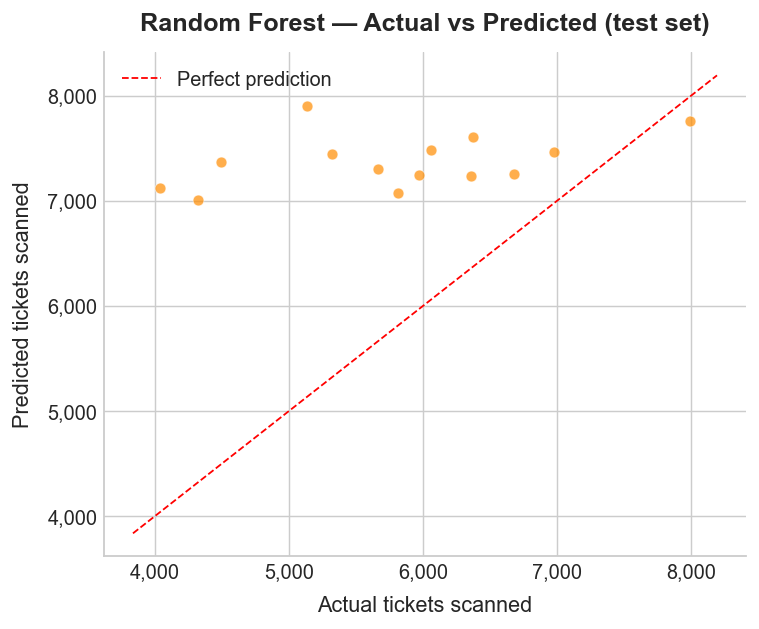

In [42]:
# --- RF: Actual vs Predicted (test set) ---
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(y_test, y_test_pred_rf, color='darkorange', alpha=0.7, edgecolors='white', linewidths=0.4)

lims = [min(y_test.min(), y_test_pred_rf.min()) - 200,
        max(y_test.max(), y_test_pred_rf.max()) + 200]
ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')

ax.set_xlabel('Actual tickets scanned')
ax.set_ylabel('Predicted tickets scanned')
ax.set_title('Random Forest — Actual vs Predicted (test set)')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

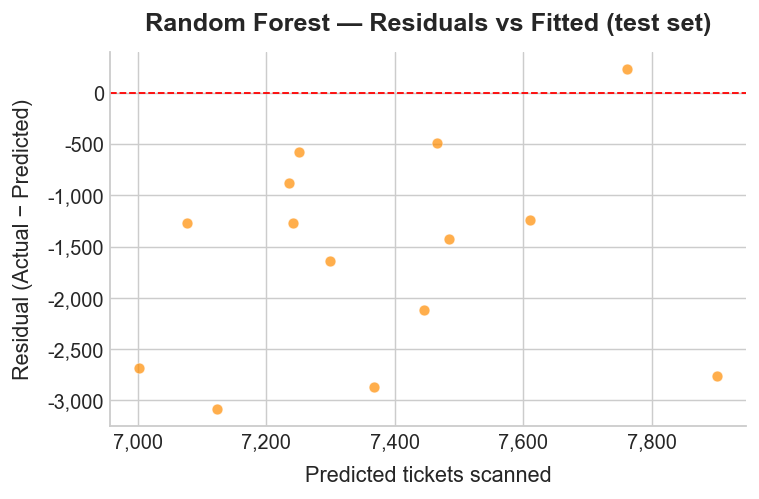

Residuals — mean: -1576.9  std: 1006.7
Largest under-predictions: [-3087. -2874. -2765.]
Largest over-predictions:  [ 230. -488. -575.]


In [43]:
# --- RF: Residuals vs Fitted (test set) ---
residuals_rf = y_test - y_test_pred_rf

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(y_test_pred_rf, residuals_rf, color='darkorange', alpha=0.7, edgecolors='white', linewidths=0.4)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Predicted tickets scanned')
ax.set_ylabel('Residual (Actual − Predicted)')
ax.set_title('Random Forest — Residuals vs Fitted (test set)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

print(f"Residuals — mean: {residuals_rf.mean():.1f}  std: {residuals_rf.std():.1f}")
print(f"Largest under-predictions: {residuals_rf.nsmallest(3).values.round(0)}")
print(f"Largest over-predictions:  {residuals_rf.nlargest(3).values.round(0)}")

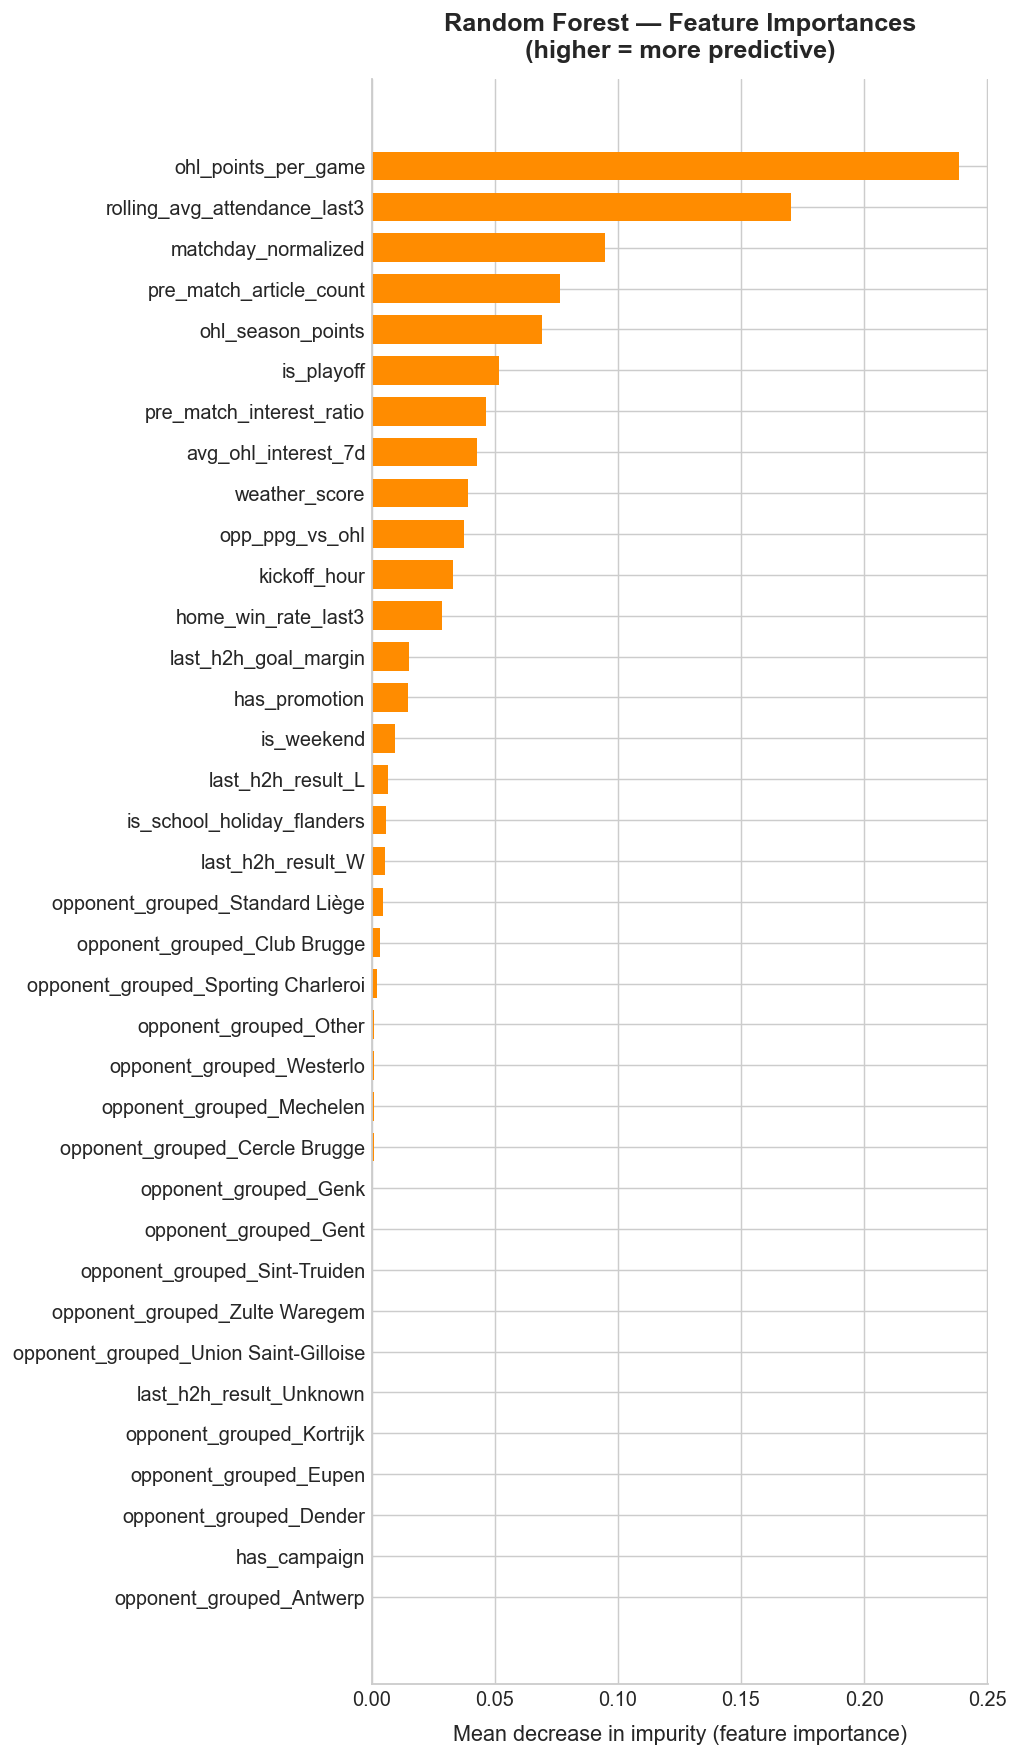

In [44]:
# --- RF: Feature importance chart ---
fi_rf = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, max(6, len(fi_rf) * 0.38)))
ax.barh(fi_rf['feature'], fi_rf['importance'], color='darkorange', height=0.7)
ax.set_xlabel('Mean decrease in impurity (feature importance)')
ax.set_title('Random Forest — Feature Importances\n(higher = more predictive)')
plt.tight_layout()
plt.show()

## 6 — Gradient Boosting

Gradient Boosting fits trees sequentially — each new tree corrects the residual errors of all previous trees.
A small learning rate with many shallow trees is standard practice that typically generalises well.

- `n_estimators=300` — 300 sequential trees
- `learning_rate=0.05` — small step size; shrinks each tree's contribution
- `max_depth=3` — shallow trees to prevent individual trees from overfitting
- `subsample=0.8` — stochastic row sampling per tree, adds regularisation
- `min_samples_leaf=3` — minimum leaf size to prevent overfit on noisy samples

In [45]:
gb = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    min_samples_leaf=3,
    random_state=42
)
gb.fit(X_train, y_train)

y_train_pred_gb = gb.predict(X_train)
y_test_pred_gb  = gb.predict(X_test)

print("Gradient Boosting fitted.")

Gradient Boosting fitted.


## 7 — Evaluation metrics (Gradient Boosting)

| Metric | Meaning |
|---|---|
| **MAE** | Average absolute error in tickets — most intuitive |
| **RMSE** | Penalises large errors more heavily |
| **R²** | Proportion of attendance variance explained (1.0 = perfect, 0 = predicts mean) |

In [46]:
gb_metrics = pd.DataFrame({
    'MAE':  [mean_absolute_error(y_train, y_train_pred_gb),
             mean_absolute_error(y_test,  y_test_pred_gb)],
    'RMSE': [root_mean_squared_error(y_train, y_train_pred_gb),
             root_mean_squared_error(y_test,  y_test_pred_gb)],
    'R²':   [r2_score(y_train, y_train_pred_gb),
             r2_score(y_test,  y_test_pred_gb)],
}, index=['Train', 'Test'])

print("=== Gradient Boosting metrics ===")
print(gb_metrics.round(3))

gap = gb_metrics.loc['Train', 'R²'] - gb_metrics.loc['Test', 'R²']
print(f"\nTrain-Test R² gap: {gap:.3f}  ", end="")
if gap > 0.15:
    print("(large gap — overfitting)")
elif gap > 0.05:
    print("(moderate gap — acceptable for this sample size)")
else:
    print("(small gap — good generalisation)")

=== Gradient Boosting metrics ===
            MAE      RMSE     R²
Train    27.640    34.781  1.000
Test   1670.892  1853.756 -2.124

Train-Test R² gap: 3.124  (large gap — overfitting)


## 8 — Diagnostics (Gradient Boosting)

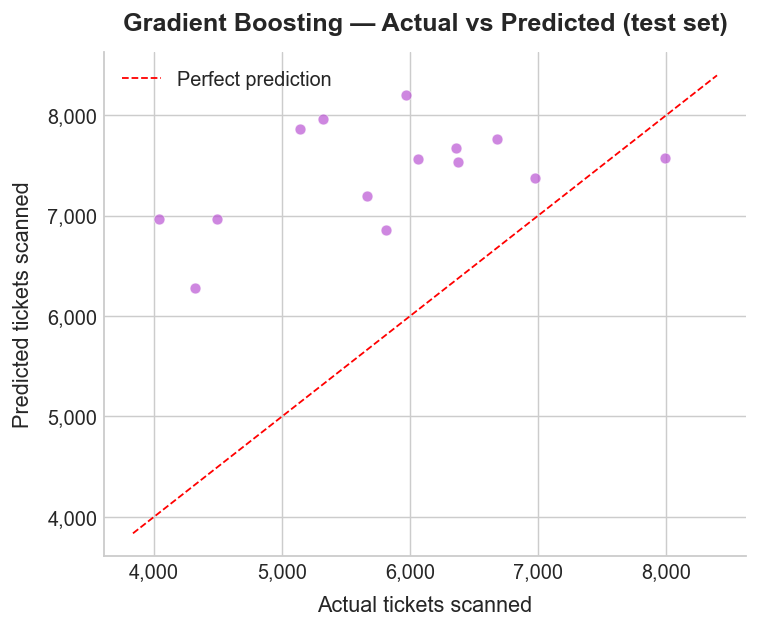

In [47]:
# --- GB: Actual vs Predicted (test set) ---
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(y_test, y_test_pred_gb, color='mediumorchid', alpha=0.7, edgecolors='white', linewidths=0.4)

lims = [min(y_test.min(), y_test_pred_gb.min()) - 200,
        max(y_test.max(), y_test_pred_gb.max()) + 200]
ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')

ax.set_xlabel('Actual tickets scanned')
ax.set_ylabel('Predicted tickets scanned')
ax.set_title('Gradient Boosting — Actual vs Predicted (test set)')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

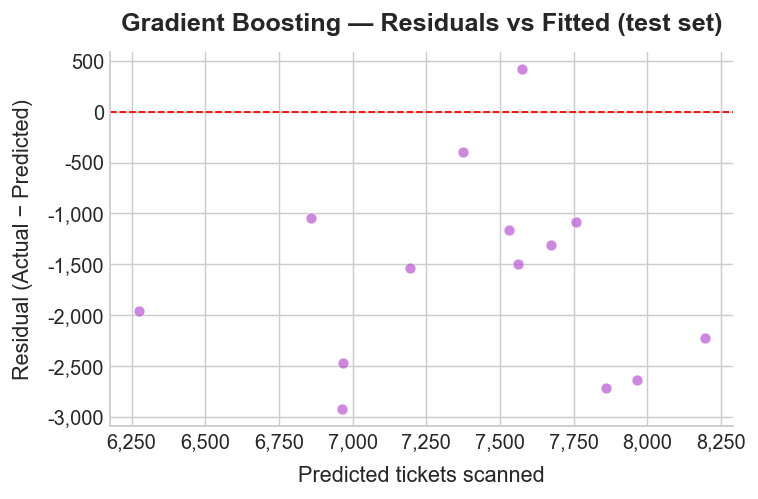

Residuals — mean: -1611.4  std: 951.1
Largest under-predictions: [-2927. -2721. -2643.]
Largest over-predictions:  [  417.  -399. -1047.]


In [48]:
# --- GB: Residuals vs Fitted (test set) ---
residuals_gb = y_test - y_test_pred_gb

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(y_test_pred_gb, residuals_gb, color='mediumorchid', alpha=0.7, edgecolors='white', linewidths=0.4)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Predicted tickets scanned')
ax.set_ylabel('Residual (Actual − Predicted)')
ax.set_title('Gradient Boosting — Residuals vs Fitted (test set)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

print(f"Residuals — mean: {residuals_gb.mean():.1f}  std: {residuals_gb.std():.1f}")
print(f"Largest under-predictions: {residuals_gb.nsmallest(3).values.round(0)}")
print(f"Largest over-predictions:  {residuals_gb.nlargest(3).values.round(0)}")

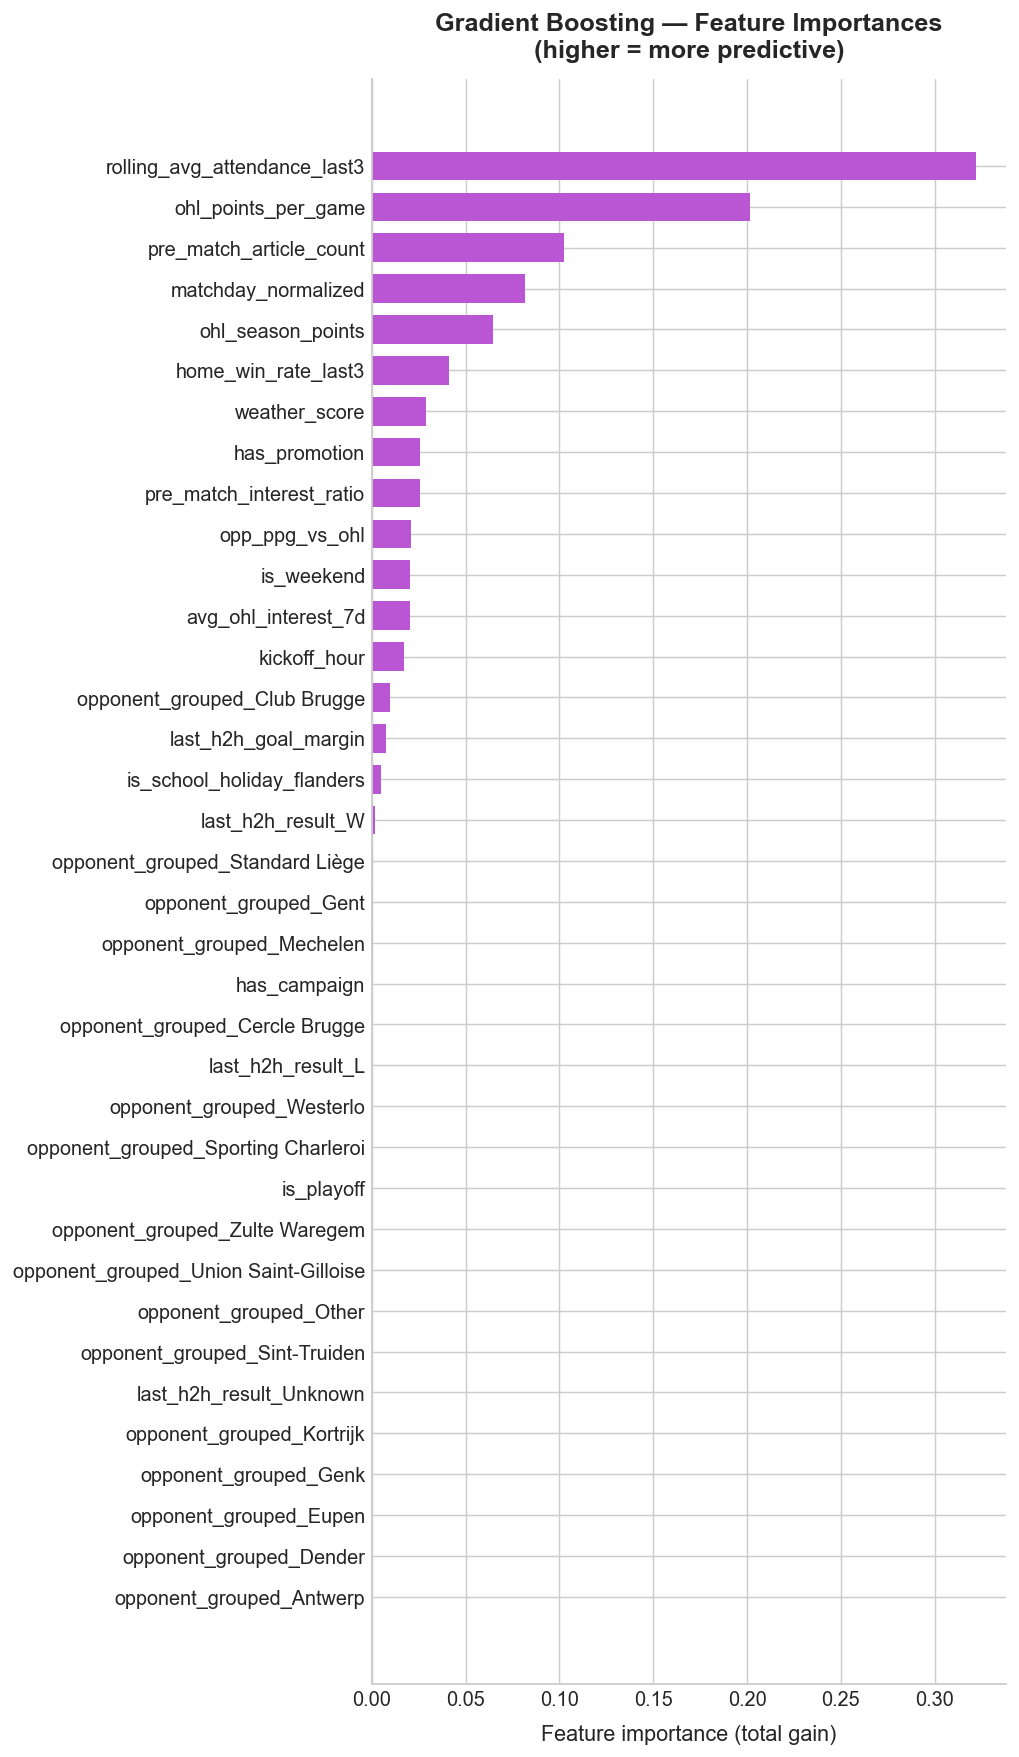

In [49]:
# --- GB: Feature importance chart ---
fi_gb = pd.DataFrame({
    'feature': X.columns,
    'importance': gb.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, max(6, len(fi_gb) * 0.38)))
ax.barh(fi_gb['feature'], fi_gb['importance'], color='mediumorchid', height=0.7)
ax.set_xlabel('Feature importance (total gain)')
ax.set_title('Gradient Boosting — Feature Importances\n(higher = more predictive)')
plt.tight_layout()
plt.show()

## 9 — Model Comparison

Side-by-side metrics, Actual vs Predicted, and feature importance charts for both models.

In [50]:
# --- Metrics comparison table ---
comparison = pd.concat(
    [rf_metrics.round(1), gb_metrics.round(1)],
    keys=['Random Forest', 'Gradient Boosting']
)
print("=== Random Forest vs Gradient Boosting ===")
print(comparison)

=== Random Forest vs Gradient Boosting ===
                            MAE    RMSE   R²
Random Forest     Train   905.4  1116.7  0.7
                  Test   1609.7  1851.4 -2.1
Gradient Boosting Train    27.6    34.8  1.0
                  Test   1670.9  1853.8 -2.1


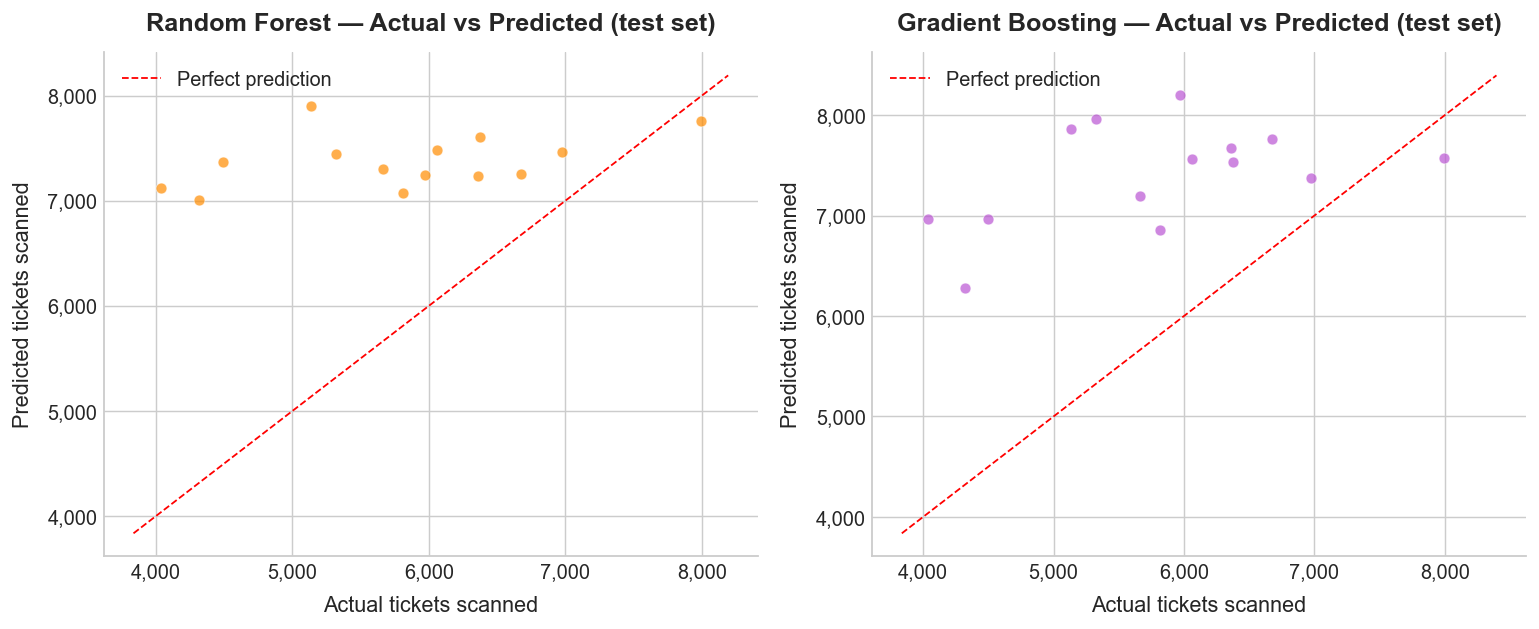

In [51]:
# --- Actual vs Predicted: RF vs GB side by side ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title, colour in zip(
    axes,
    [y_test_pred_rf, y_test_pred_gb],
    ['Random Forest', 'Gradient Boosting'],
    ['darkorange', 'mediumorchid']
):
    ax.scatter(y_test, preds, color=colour, alpha=0.7, edgecolors='white', linewidths=0.4)
    lims = [min(y_test.min(), preds.min()) - 200, max(y_test.max(), preds.max()) + 200]
    ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
    ax.set_xlabel('Actual tickets scanned')
    ax.set_ylabel('Predicted tickets scanned')
    ax.set_title(f'{title} — Actual vs Predicted (test set)')
    ax.legend()
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

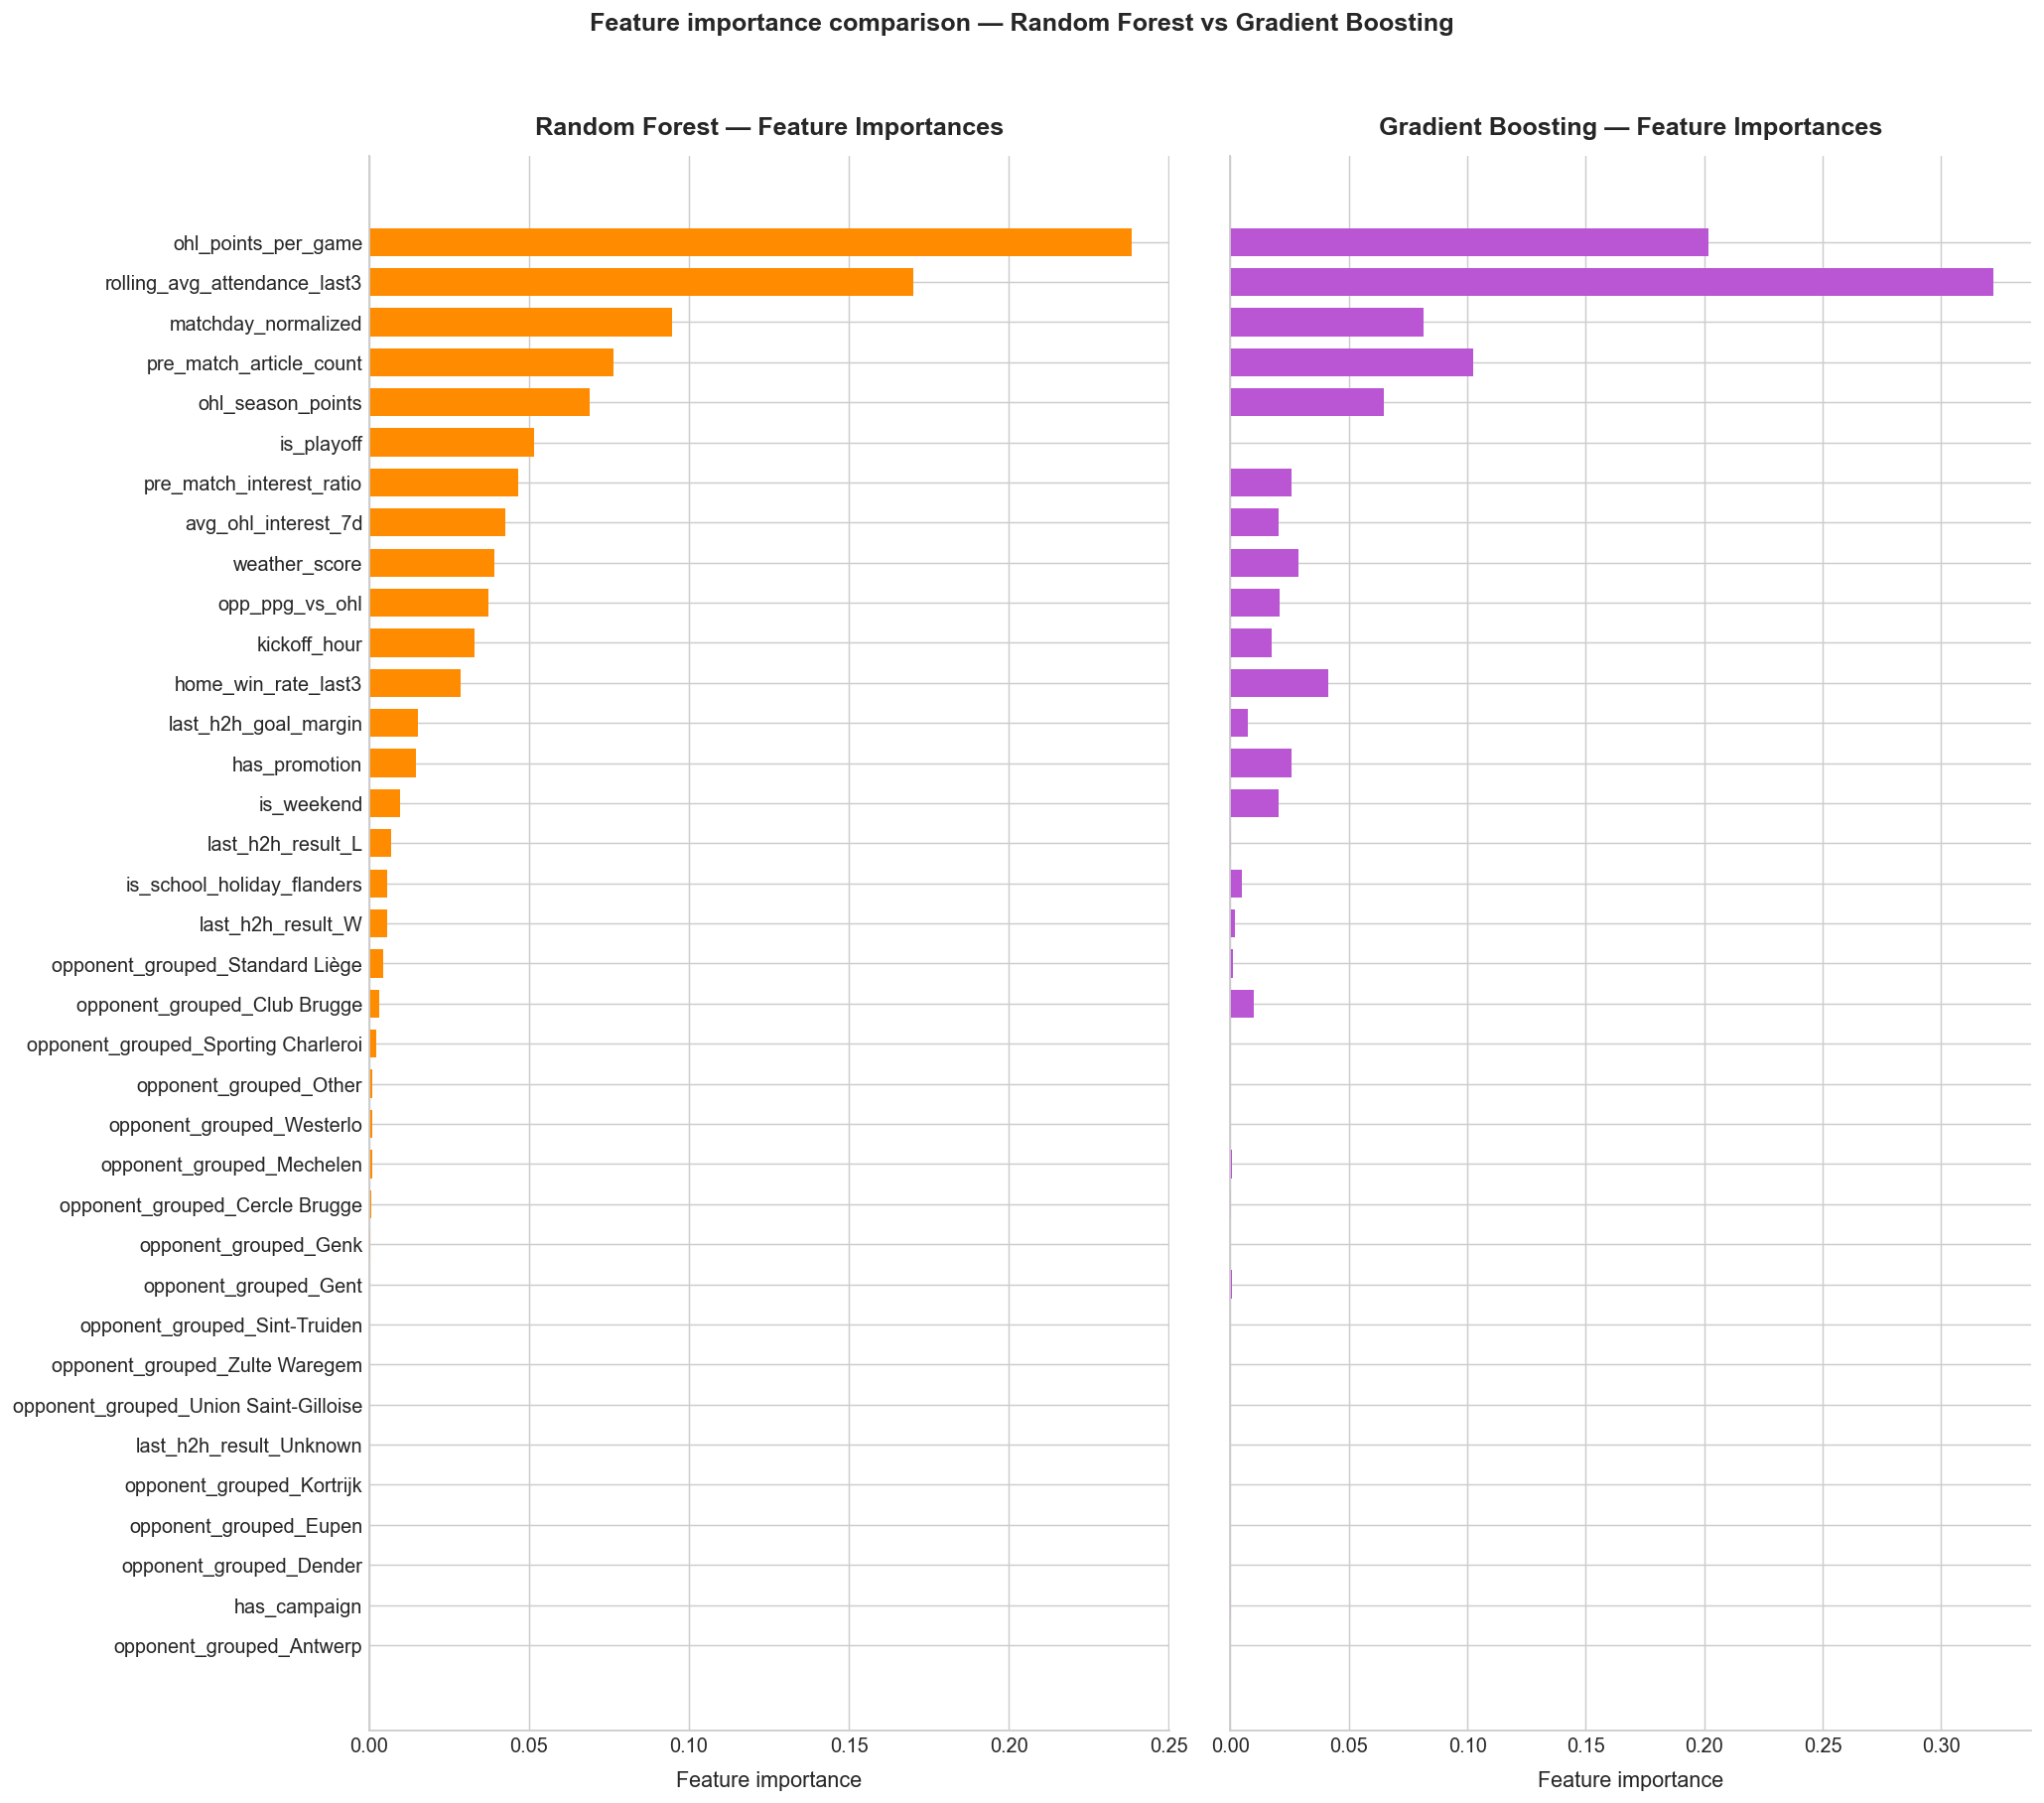

In [52]:
# --- Feature importance comparison: RF vs GB side by side ---
fi_compare = pd.DataFrame({
    'Random Forest':     rf.feature_importances_,
    'Gradient Boosting': gb.feature_importances_,
}, index=X.columns).sort_values('Random Forest', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(fi_compare) * 0.38)), sharey=True)

for ax, col, colour, title in zip(
    axes,
    ['Random Forest', 'Gradient Boosting'],
    ['darkorange', 'mediumorchid'],
    ['Random Forest — Feature Importances', 'Gradient Boosting — Feature Importances']
):
    ax.barh(fi_compare.index, fi_compare[col], color=colour, height=0.7)
    ax.set_xlabel('Feature importance')
    ax.set_title(title)

fig.suptitle(
    'Feature importance comparison — Random Forest vs Gradient Boosting',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

## 10 — Cross-validated scores

With only 57 training rows a single train/test split can be noisy.
5-fold cross-validation on the training set gives a more stable estimate of generalisation performance.

In [53]:
for name, model in [('Random Forest', rf), ('Gradient Boosting', gb)]:
    cv_r2  = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    cv_mae = -cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
    print(f"{name}")
    print(f"  CV R²  : {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
    print(f"  CV MAE : {cv_mae.mean():.0f} ± {cv_mae.std():.0f}")
    print()

Random Forest
  CV R²  : -1.526 ± 1.806
  CV MAE : 1626 ± 249

Gradient Boosting
  CV R²  : -1.747 ± 1.588
  CV MAE : 1633 ± 147



## 11 — Lift Curve

A lift curve measures the **practical ranking value** of each model — independent of raw prediction accuracy.

Test matches are sorted by predicted attendance (highest to lowest). At each step we ask: *of the top X% of matches the model flags as high-attendance, what is their average actual attendance?* This is compared against the **baseline** — randomly selecting matches, which gives the overall mean.

The area between the model curve and the baseline is the **lift**: how much smarter the model's ranking is than chance. This directly answers OHL's business question:
> *"If we allocate promotional budget to the matches our model ranks highest, how much better is that than spreading budget randomly?"*

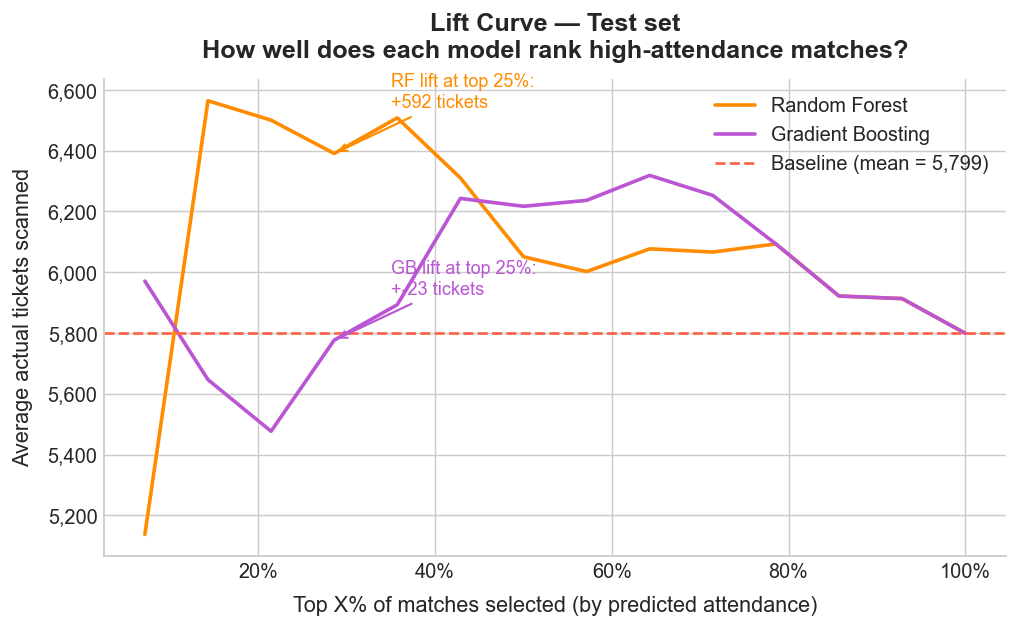

In [54]:
def lift_curve_data(y_true, y_pred):
    """
    Sort by predicted value descending, compute cumulative mean actual
    attendance at each step as a percentage of the dataset selected.
    Returns (pct_selected, cum_mean_actual).
    """
    order = np.argsort(y_pred)[::-1]
    y_sorted = np.array(y_true)[order]
    n = len(y_sorted)
    cum_means = np.cumsum(y_sorted) / np.arange(1, n + 1)
    pct = np.arange(1, n + 1) / n * 100
    return pct, cum_means


baseline = y_test.mean()

pct_rf, mean_rf = lift_curve_data(y_test, y_test_pred_rf)
pct_gb, mean_gb = lift_curve_data(y_test, y_test_pred_gb)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(pct_rf, mean_rf, color='darkorange',   linewidth=2, label='Random Forest')
ax.plot(pct_gb, mean_gb, color='mediumorchid', linewidth=2, label='Gradient Boosting')
ax.axhline(baseline, color='tomato', linestyle='--', linewidth=1.5,
           label=f'Baseline (mean = {baseline:,.0f})')

ax.set_xlabel('Top X% of matches selected (by predicted attendance)')
ax.set_ylabel('Average actual tickets scanned')
ax.set_title('Lift Curve — Test set\nHow well does each model rank high-attendance matches?')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}%'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Annotate lift at top 25%
for pct_arr, mean_arr, colour, name in [
    (pct_rf, mean_rf, 'darkorange',   'RF'),
    (pct_gb, mean_gb, 'mediumorchid', 'GB'),
]:
    idx = np.searchsorted(pct_arr, 25)
    lift_val = mean_arr[idx] - baseline
    ax.annotate(
        f'{name} lift at top 25%:\n+{lift_val:,.0f} tickets',
        xy=(pct_arr[idx], mean_arr[idx]),
        xytext=(35, mean_arr[idx] + 150),
        fontsize=10,
        color=colour,
        arrowprops=dict(arrowstyle='->', color=colour, lw=1.2),
    )

plt.tight_layout()
plt.show()